In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math

csv_path=r"C:\Users\Administrator\Desktop\Chess\data\input\temp2.8.csv"
df=pd.read_csv(csv_path)

In [2]:
df=df.drop(columns=['row_idx', 'Complexity P', 'Complexity S','White Complexity Sum', 'Black Complexity Sum','Stage Analysis'])
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r'\s+', '_', regex=True)
)
df.columns

Index(['UID', 'White', 'Black', 'White_CP_Loss', 'White_Accuracy',
       'Black_CP_Loss', 'Black_Accuracy', 'Evaluation', 'ComplexityE',
       'Judgments', 'White_Blunders', 'White_Mistakes', 'White_Inaccuracies',
       'Black_Blunders', 'Black_Mistakes', 'Black_Inaccuracies',
       'Complexity_E1', 'Complexity_E2', 'Complexity_E3', 'Complexity_E4',
       'Complexity_E5'],
      dtype='object')

In [3]:
df.head()

,UID,White,Black,White_CP_Loss,White_Accuracy,Black_CP_Loss,Black_Accuracy,Evaluation,ComplexityE,Judgments,...,White_Mistakes,White_Inaccuracies,Black_Blunders,Black_Mistakes,Black_Inaccuracies,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,21.9,95.8,52.1,90.7,"0.33,0.36,0.30,0.44,0.32,0.39,0.40,0.39,0.32,0...","33,36,30,44,32,39,40,39,32,50,42,66,56,70,58,8...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inaccu...",...,1,2,2,1,1,"36,33,36,30,44,32,39,40,39,32,50,42,66,56,70,5...","34,34,33,63,35,37,38,47,23,46,40,55,58,57,55,6...","31,34,27,66,26,67,36,60,17,49,29,55,48,65,29,7...","25,42,25,78,21,71,34,67,12,52,26,57,35,74,28,8...","16,48,20,79,21,72,25,83,11,53,18,62,28,90,27,9..."
1,35,AradNazari,Andre Bold,23.5,96.5,58.1,91.2,"0.28,0.37,0.39,0.36,0.18,0.14,0.36,0.42,0.40,0...","28,37,39,36,18,14,36,42,40,35,37,41,35,35,34,3...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,0,1,2,1,2,"31,28,37,39,36,18,14,36,42,40,35,37,41,35,35,3...","30,30,33,40,35,93,-22,36,2,41,19,76,29,262,-46...","28,31,27,41,32,141,-55,39,-12,42,1,80,20,276,-...","23,31,27,43,28,141,-67,47,-22,52,-13,92,5,345,...","12,50,26,45,16,180,-85,48,-51,52,-19,119,-3,38..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,36.5,89.7,17.4,94.4,"0.29,0.59,0.33,0.43,0.11,0.17,0.06,0.19,0.05,0...","29,59,33,43,11,17,6,19,5,9,-1,17,11,11,13,27,1...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inac...",...,0,5,0,0,2,"25,29,59,33,43,11,17,6,19,5,9,-1,17,11,11,13,2...","21,31,44,44,29,29,10,9,16,17,0,5,11,13,7,13,19...","20,31,40,55,14,36,8,12,3,17,-4,11,11,14,3,14,1...","13,32,33,60,9,41,8,23,0,19,-7,12,8,19,3,16,16,...","10,54,22,64,9,46,8,29,0,21,-18,17,8,22,3,18,10..."
3,37,Bartosz Przybylski,Joseph Ryan,33.2,92.4,71.0,87.5,"0.22,0.39,0.36,0.51,0.42,0.48,0.37,0.44,0.28,0...","22,39,36,51,42,48,37,44,28,26,37,66,66,64,71,5...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,0,1,2,2,1,"29,22,39,36,51,42,48,37,44,28,26,37,66,66,64,7...","25,23,33,37,43,53,26,37,39,28,21,58,-8,66,49,9...","21,27,21,41,33,59,22,38,26,29,0,60,-23,69,49,1...","13,28,19,47,32,67,15,38,0,31,-22,80,-41,104,47...","7,48,10,51,25,68,1,39,-7,35,-25,87,-57,111,40,..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,26.9,92.7,38.5,89.6,"0.31,0.28,0.28,0.36,0.30,0.39,0.39,0.39,0.31,0...","31,28,28,36,30,39,39,39,31,35,31,30,15,27,20,2...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,3,1,1,3,4,"35,31,28,28,36,30,39,39,39,31,35,31,30,15,27,2...","32,32,27,30,29,33,26,210,35,33,20,32,25,114,23...","20,32,15,35,25,35,23,212,30,36,17,35,23,398,22...","17,33,12,50,22,39,16,215,23,37,16,35,16,519,15...","17,43,6,60,16,40,15,229,22,43,13,37,12,521,13,..."


In [4]:
MISSING = '__MISSING__'
def split_with_missing_marker(x, marker='__MISSING__'):
    if not isinstance(x, str):
        return x

    tokens = x.split(',')
    return [t if t.strip() != '' else marker for t in tokens]

def parse_chess_data(df):
    list_cols = [
        'Judgments',
        'ComplexityE', 'Complexity_E1', 'Complexity_E2',
        'Complexity_E3', 'Complexity_E4', 'Complexity_E5'
    ]

    # 1️ 复杂度列：只 split + 标记缺失，不转 float
    for col in list_cols:
        if col != 'Judgments':
            df[col] = df[col].apply(
                lambda x: split_with_missing_marker(x, marker=MISSING)
                if isinstance(x, str) else x
            )

    # 2️ Judgments 单独处理（它不涉及 float）
    df['Judgments'] = df['Judgments'].apply(
        lambda x: x.split(',') if isinstance(x, str) else x
    )

    return df


df=parse_chess_data(df)
df.head()

,UID,White,Black,White_CP_Loss,White_Accuracy,Black_CP_Loss,Black_Accuracy,Evaluation,ComplexityE,Judgments,...,White_Mistakes,White_Inaccuracies,Black_Blunders,Black_Mistakes,Black_Inaccuracies,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,21.9,95.8,52.1,90.7,"0.33,0.36,0.30,0.44,0.32,0.39,0.40,0.39,0.32,0...","[33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 42, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,1,2,2,1,1,"[36, 33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 4...","[34, 34, 33, 63, 35, 37, 38, 47, 23, 46, 40, 5...","[31, 34, 27, 66, 26, 67, 36, 60, 17, 49, 29, 5...","[25, 42, 25, 78, 21, 71, 34, 67, 12, 52, 26, 5...","[16, 48, 20, 79, 21, 72, 25, 83, 11, 53, 18, 6..."
1,35,AradNazari,Andre Bold,23.5,96.5,58.1,91.2,"0.28,0.37,0.39,0.36,0.18,0.14,0.36,0.42,0.40,0...","[28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 37, 4...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,0,1,2,1,2,"[31, 28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 3...","[30, 30, 33, 40, 35, 93, -22, 36, 2, 41, 19, 7...","[28, 31, 27, 41, 32, 141, -55, 39, -12, 42, 1,...","[23, 31, 27, 43, 28, 141, -67, 47, -22, 52, -1...","[12, 50, 26, 45, 16, 180, -85, 48, -51, 52, -1..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,36.5,89.7,17.4,94.4,"0.29,0.59,0.33,0.43,0.11,0.17,0.06,0.19,0.05,0...","[29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, 17, ...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,0,5,0,0,2,"[25, 29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, ...","[21, 31, 44, 44, 29, 29, 10, 9, 16, 17, 0, 5, ...","[20, 31, 40, 55, 14, 36, 8, 12, 3, 17, -4, 11,...","[13, 32, 33, 60, 9, 41, 8, 23, 0, 19, -7, 12, ...","[10, 54, 22, 64, 9, 46, 8, 29, 0, 21, -18, 17,..."
3,37,Bartosz Przybylski,Joseph Ryan,33.2,92.4,71.0,87.5,"0.22,0.39,0.36,0.51,0.42,0.48,0.37,0.44,0.28,0...","[22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 37, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,0,1,2,2,1,"[29, 22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 3...","[25, 23, 33, 37, 43, 53, 26, 37, 39, 28, 21, 5...","[21, 27, 21, 41, 33, 59, 22, 38, 26, 29, 0, 60...","[13, 28, 19, 47, 32, 67, 15, 38, 0, 31, -22, 8...","[7, 48, 10, 51, 25, 68, 1, 39, -7, 35, -25, 87..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,26.9,92.7,38.5,89.6,"0.31,0.28,0.28,0.36,0.30,0.39,0.39,0.39,0.31,0...","[31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 31, 3...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,3,1,1,3,4,"[35, 31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 3...","[32, 32, 27, 30, 29, 33, 26, 210, 35, 33, 20, ...","[20, 32, 15, 35, 25, 35, 23, 212, 30, 36, 17, ...","[17, 33, 12, 50, 22, 39, 16, 215, 23, 37, 16, ...","[17, 43, 6, 60, 16, 40, 15, 229, 22, 43, 13, 3..."


In [5]:
MISSING = '__MISSING__'

complexity_cols = [
    'ComplexityE', 'Complexity_E1', 'Complexity_E2',
    'Complexity_E3', 'Complexity_E4', 'Complexity_E5'
]

total_missing = 0

for col in complexity_cols:
    total_missing += df[col].apply(
        lambda x: x.count(MISSING) if isinstance(x, list) else 0
    ).sum()

total_missing

np.int64(1000249)

In [6]:
df.shape

(104103, 21)

In [7]:
missing_by_col = {}

for col in df.columns:
    missing_by_col[col] = df[col].apply(
        lambda x: sum(1 for i in x if i == '__MISSING__') if isinstance(x, list) else 0
    ).sum()

missing_by_col

{'UID': np.int64(0),
 'White': np.int64(0),
 'Black': np.int64(0),
 'White_CP_Loss': np.int64(0),
 'White_Accuracy': np.int64(0),
 'Black_CP_Loss': np.int64(0),
 'Black_Accuracy': np.int64(0),
 'Evaluation': np.int64(0),
 'ComplexityE': np.int64(0),
 'Judgments': np.int64(0),
 'White_Blunders': np.int64(0),
 'White_Mistakes': np.int64(0),
 'White_Inaccuracies': np.int64(0),
 'Black_Blunders': np.int64(0),
 'Black_Mistakes': np.int64(0),
 'Black_Inaccuracies': np.int64(0),
 'Complexity_E1': np.int64(0),
 'Complexity_E2': np.int64(66506),
 'Complexity_E3': np.int64(179086),
 'Complexity_E4': np.int64(311977),
 'Complexity_E5': np.int64(442680)}

In [8]:
def explode_chess_data(row):
    game_id = row['UID']
    white = row['White']
    black = row['Black']
    Es=row['ComplexityE']
    E1s=row['Complexity_E1']
    E2s=row['Complexity_E2']
    E3s=row['Complexity_E3']
    E4s=row['Complexity_E4']
    E5s=row['Complexity_E5']

    judgments = row['Judgments']
    if not isinstance(Es, list):
        Es = []
    if not isinstance(E1s, list):
        E1s = []
    if not isinstance(E2s, list):
        E2s = []   
    if not isinstance(E3s, list):
        E3s = [] 
    if not isinstance(E4s, list):
        E4s = []   
    if not isinstance(E5s, list):
        E5s = [] 
    if not isinstance(judgments, list):
        judgments = []

    length = len(judgments)
    exploded_data = []
    
    for i in range(length):
        # 偶数步是白方，奇数步是黑方 (0, 1, 2, 3...)
        is_white_move = (i % 2 == 0)
        player_name = white if is_white_move else black
        
        judgment_str = judgments[i]
        
        # 标记是否为失误
        is_error = 1 if judgment_str in ['Blunder', 'Mistake'] else 0
        is_blunder = 1 if judgment_str == 'Blunder' else 0
        
        exploded_data.append({
            'uid': game_id,
            'Move_Idx': i + 1,        # 人类习惯从第1步开始
            'Player': player_name,
            'Color': 'White' if is_white_move else 'Black',
            'E': Es[i],
            'E1':E1s[i],
            'E2':E2s[i],
            'E3':E3s[i],
            'E4':E4s[i],
            'E5':E5s[i],
            'Judgment_Raw': judgment_str,
            'Is_Error': is_error,     # 关键指标：所有失误
            'Is_Blunder': is_blunder  # 关键指标：大失误
        })
        
    return exploded_data
all_moves = []

for row in tqdm(df.itertuples(index=False), total=len(df)):
    moves = explode_chess_data(row._asdict())
    all_moves.extend(moves)

df_moves = pd.DataFrame(all_moves)
df_moves.head()

  0%|          | 0/104103 [00:00<?, ?it/s]

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0


check about the missing

In [9]:
def is_missing(x):
    return (x is None) or (isinstance(x, str) and x == '__MISSING__') or pd.isna(x)
cols_to_show = [
    'uid', 'Move_Idx', 'Player', 'Color',
    'E1', 'E2', 'E3', 'E4', 'E5'
]

df_E2_missing = df_moves[df_moves['E5'].progress_apply(is_missing)][cols_to_show]
#display(df_E2_missing.head(50))

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [10]:
df_moves[['E', 'E1', 'E2', 'E3', 'E4', 'E5']].map(type).value_counts()

E              E1             E2             E3             E4             E5           
<class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>    9086334
Name: count, dtype: int64

In [11]:
numeric_cols = ['E', 'E1']

for col in numeric_cols:
    df_moves[col] = pd.to_numeric(df_moves[col], errors='coerce')

In [12]:
#white E1-E   black E-E1
def safe_sub(a, b):
    """安全减法函数：先转换为浮点数，失败则返回NaN"""
    try:
        a = float(a)
        b = float(b)
    except (TypeError, ValueError):
        return np.nan
    return a - b

# 定义按颜色计算差值的函数
def calculate_delta(row):
    color = row['Color']
    # 根据Color分支计算
    if color == 'White':
        # White: E1 - E
        return safe_sub(row['E1'], row['E'])
    elif color == 'Black':
        # Black: E - E1
        return safe_sub(row['E'], row['E1'])
    else:
        # 非White/Black的情况返回NaN
        return np.nan

# 应用函数生成Δi列
df_moves['Δi'] = df_moves.progress_apply(calculate_delta, axis=1)

# 查看结果
df_moves.head(20)
print(df_moves['Δi'].describe())

  0%|          | 0/9086334 [00:00<?, ?it/s]

count    9.086334e+06
mean     1.203234e+02
std      1.019978e+03
min     -9.814000e+03
25%      0.000000e+00
50%      8.000000e+00
75%      3.100000e+01
max      1.999800e+04
Name: Δi, dtype: float64


# Δ (Decision Margin)

For a given move decision, define the core parameters:

- $E_1$: evaluation of the best move  
- $E_k$: evaluation of the $k$-th best move, $k \in \{2,3,4,5\}$  
- $w_k$: weight assigned to the $k$-th best move, fixed as:

$$
w_2 = 0.4,\quad w_3 = 0.3,\quad w_4 = 0.2,\quad w_5 = 0.1
$$

Let the **set of available alternative moves** be:

$$
\mathcal{K} = \{\, k \in \{2,3,4,5\} \mid E_k \text{ is available} \,\}
$$

## White move

$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_1 - E_k)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## Black move

$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_k - E_1)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## Special case

If $\mathcal{K} = \varnothing$ (i.e., only the best move $E_1$ exists and no alternative moves are available), define:

$$
\Delta = 0
$$

## Notes

1. Only **consecutively available** $E_2, E_3, \dots$ are used. Once some $E_k$ is missing, all subsequent terms are excluded from the computation.  
2. In practice, the weights involved in the current computation are **normalized**.  
3. White/Black only affects the **sign direction** of $\Delta$, without changing its magnitude scale.

# Δ （Decision Margin）
设在某一步走法决策中，定义核心参数：
- $E_1$：最优走法的评估值
- $E_k$：第 $k$ 优走法的评估值，$k \in \{2,3,4,5\}$
- $w_k$：第 $k$ 优走法对应的权重，固定为：

$$
w_2 = 0.4,\quad w_3 = 0.3,\quad w_4 = 0.2,\quad w_5 = 0.1
$$

记**存在的备选走法集合**为：
$$
\mathcal{K} = \{\, k \in \{2,3,4,5\} \mid E_k \text{ is available} \,\}
$$

## 白方走法（White move）
$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_1 - E_k)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## 黑方走法（Black move）
$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_k - E_1)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## 特殊情况（Special case）
若 $\mathcal{K} = \varnothing$（仅存在最优走法 $E_1$，无任何备选走法），定义：
$$
\Delta = 0
$$

## 注意事项（Notes）
1. 仅使用**连续存在**的 $E_2, E_3, \dots$，一旦某一 $E_k$ 缺失，后续所有项均不再参与计算；
2. 实际计算中，对本次参与运算的权重进行**归一化**处理；
3. 白方/黑方仅影响 $\Delta$ 的**符号方向**，不改变其数值尺度。

In [13]:
def compute_delta(row):
    Ei_cols=['E2', 'E3', 'E4', 'E5']
    color = row['Color']
    weights={'E2':0.4, 'E3':0.3, 'E4':0.2, 'E5':0.1}
    total_weight = 0.0
    E1 = row['E1']
    if pd.isna(E1): return np.nan

    delta = 0.0
    used_any = False

    for col in Ei_cols:
        Ei = row[col]
        try:
            Ei = float(Ei)
        except (TypeError, ValueError):
            break
        
        if pd.isna(Ei):
            break
        w =weights[col]
        total_weight += w
        if color =='White':
            delta += w*(E1 - Ei)
        else:
            delta += w*(Ei - E1)
        used_any = True

    if not used_any:
        return 0.0
    
    return round(delta/total_weight)


df_moves['Δ'] = df_moves.progress_apply(compute_delta, axis=1)

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [14]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0


In [15]:
elo_info=pd.read_csv(r"C:\Users\Administrator\Desktop\Chess\ELO\temp.csv",usecols=['uid','player', 'My_Elo'] )
elo_info=elo_info[['uid','player', 'My_Elo']].rename(columns={'My_Elo':'ELO'})
elo_info=elo_info.set_index(['uid', 'player'])['ELO']
df_moves = df_moves.merge(
    elo_info,
    left_on=['uid', 'Player'],   # df_moves 中的列
    right_on=['uid', 'player'],      # elo_info 中的列
    how='left'
)
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802


In [16]:
def elo_group(elo):
    if elo < 2000:
        return '<2000'
    elif 2000<= elo < 2200:
        return '2000-2200'
    elif 2200<= elo <2400:
        return '2200-2400'
    elif 2400<=elo<2600:
        return '2400-2600'
    elif 2600<=elo<2800:
        return '2600-2800'
    elif 2800<=elo<3000:
        return '2800-3000'
    else:
        return '>=3000'

df_moves['ELO_Group'] = df_moves['ELO'].apply(elo_group)
df_moves['ELO_Group'].value_counts(normalize=True)

ELO_Group
2400-2600    0.335266
2600-2800    0.236182
2200-2400    0.183996
2800-3000    0.133464
>=3000       0.051139
2000-2200    0.048955
<2000        0.010998
Name: proportion, dtype: float64

In [17]:
force_moves_csv=r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_moves_df=pd.read_csv(force_moves_csv)
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [int(x)]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [int(v)]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

force_moves_df['Forced_Move_Idx_List'] = force_moves_df['Forced_Move_Idx_List'].apply(ensure_list)

forced_expanded = []

for idx, row in force_moves_df.iterrows():
    game_id = row['Game_ID']
    for move_idx in row['Forced_Move_Idx_List']:
        forced_expanded.append({'Game_ID': game_id, 'Move_Idx': move_idx, 'Is_Forced': 1})

df_forced_expanded = pd.DataFrame(forced_expanded, columns=['Game_ID', 'Move_Idx', 'Is_Forced'])

cols_to_drop = [col for col in df_moves.columns if 'Is_Forced' in col]
df_moves = df_moves.drop(columns=cols_to_drop)

df_moves = df_moves.merge(df_forced_expanded, left_on=['uid', 'Move_Idx'],   # df_moves 的列名
    right_on=['Game_ID', 'Move_Idx'],  # df_forced_expanded 的列名
    how='left')
df_moves['Is_Forced'] = df_moves['Is_Forced'].fillna(0).astype(int)
df_moves['Is_Forced'].value_counts()
df_moves = df_moves.drop(columns=['Game_ID'])

In [18]:
tolerance_cp= 10
df_moves['Is_Optimal'] = np.where(df_moves['Δi'] <= tolerance_cp, 1, 0)
#df_moves.head(50)

In [19]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0


In [20]:
df_moves['Δ'].describe

<bound method NDFrame.describe of 0            7.0
1            4.0
2            8.0
3           39.0
4           16.0
           ...  
9086329     85.0
9086330     10.0
9086331     15.0
9086332     10.0
9086333    263.0
Name: Δ, Length: 9086334, dtype: float64>


===== ELO group: >=3000 =====


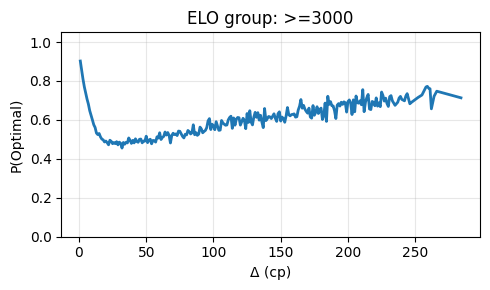

A        = 0.772
0.73 * A = 0.563
Δ0       = 105.31668244989947

===== ELO group: 2800-3000 =====


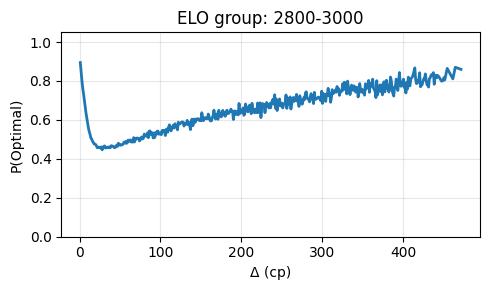

A        = 0.749
0.73 * A = 0.547
Δ0       = 113.28957967385827

===== ELO group: 2600-2800 =====


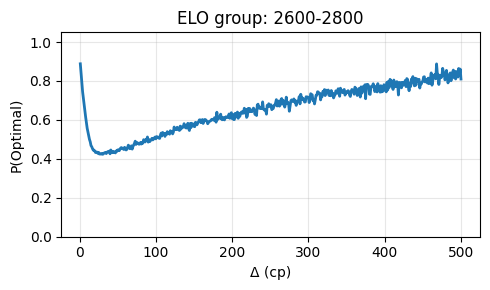

A        = 0.733
0.73 * A = 0.535
Δ0       = 118.45685746204633

===== ELO group: 2400-2600 =====


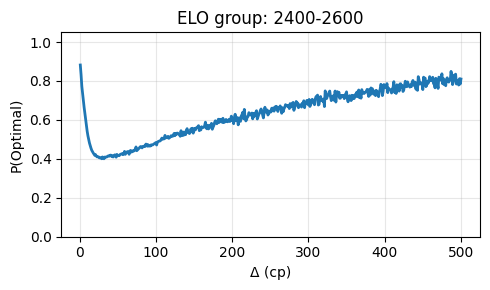

A        = 0.712
0.73 * A = 0.519
Δ0       = 122.47921808372658

===== ELO group: 2200-2400 =====


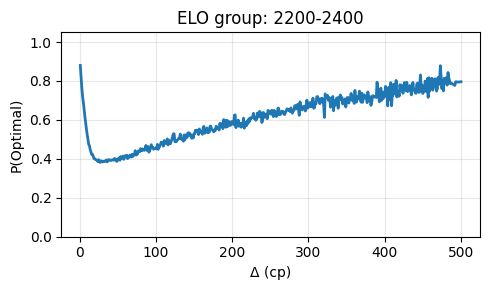

A        = 0.691
0.73 * A = 0.505
Δ0       = 138.29762964095053

===== ELO group: 2000-2200 =====


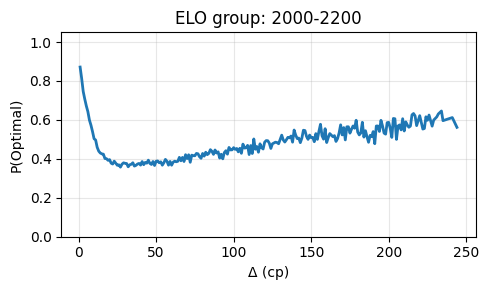

A        = 0.679
0.73 * A = 0.496
Δ0       = 129.8032990010252

===== ELO group: <2000 =====


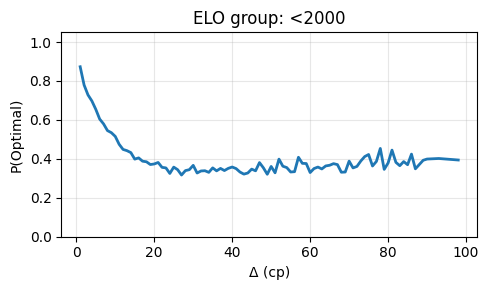

A        = 0.656
0.73 * A = 0.479
Δ0       = None


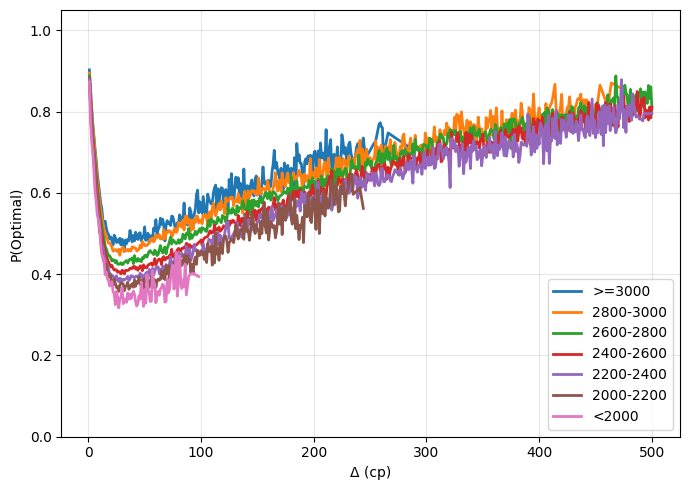

In [21]:
def empirical_curve(df, group_name, delta_max=500, min_count=100, show_plot=True):
    group_df = df[(df['ELO_Group'] == group_name) & (df['Is_Forced'] == 0)]
    group_df = group_df[(group_df['Δ'] > 0) & (group_df['Δ'] <= delta_max)]

    if group_df.empty:
        return None

    counts = group_df.groupby('Δ')['Is_Optimal'].count()
    valid_deltas = counts[counts >= min_count].index
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty:
        return None

    prob_df = (
        group_df
        .groupby('Δ')['Is_Optimal']
        .mean()
        .reset_index()
        .rename(columns={'Is_Optimal': 'P_Optimal'})
        .sort_values('Δ')
        .reset_index(drop=True)
    )

    if show_plot:
        plt.figure(figsize=(5,3))
        plt.plot(prob_df['Δ'], prob_df['P_Optimal'], lw=2)
        plt.title(f'ELO group: {group_name}')
        plt.xlabel('Δ (cp)')
        plt.ylabel('P(Optimal)')
        plt.ylim(0, 1.05)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return prob_df


def get_right_branch(prob_df):
    df = prob_df.sort_values('Δ').reset_index(drop=True)
    idx_min = df['P_Optimal'].idxmin()
    return df.loc[idx_min:].reset_index(drop=True)


def get_empirical_delta0_right(prob_df, target_prob):
    if prob_df is None or prob_df.empty:
        return None

    right_df = get_right_branch(prob_df)
    x = right_df['Δ'].values
    y = right_df['P_Optimal'].values

    if target_prob < y.min() or target_prob > y.max():
        return None

    return float(np.interp(target_prob, y, x))


def get_empirical_ceiling(df, group_name, delta_lo=200, delta_hi=1000):
    sub = df[
        (df['ELO_Group'] == group_name) &
        (df['Δ'] > delta_lo) &
        (df['Δ'] <= delta_hi)
    ]
    if sub.empty:
        return None
    return sub['Is_Optimal'].mean()
group_order = ['>=3000', '2800-3000', '2600-2800',
               '2400-2600', '2200-2400', '2000-2200', '<2000']

all_prob_curves = {}
results = {}

for g in group_order:
    print(f'\n===== ELO group: {g} =====')

    prob_df = empirical_curve(
        df_moves,
        group_name=g,
        delta_max=500,
        min_count=200,
        show_plot=True
    )

    if prob_df is None:
        print('No valid data.')
        continue

    A = get_empirical_ceiling(df_moves, g)
    if A is None:
        print('No ceiling A.')
        continue

    A_073 = 0.73 * A
    delta0 = get_empirical_delta0_right(prob_df, A_073)

    print(f'A        = {A:.3f}')
    print(f'0.73 * A = {A_073:.3f}')
    print(f'Δ0       = {delta0}')

    all_prob_curves[g] = prob_df
    results[g] = {
        'A': A,
        'A_073': A_073,
        'delta0': delta0
    }

def plot_all_groups(all_prob_curves):
    plt.figure(figsize=(7,5))

    for g in group_order:
        if g not in all_prob_curves:
            continue
        df = all_prob_curves[g]
        plt.plot(df['Δ'], df['P_Optimal'], lw=2, label=g)

    plt.xlabel('Δ (cp)')
    plt.ylabel('P(Optimal)')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_all_groups(all_prob_curves)


In [22]:
clock_info = pd.read_csv(r'..\..\data\input\clock_info.csv')
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())

white_sec
<class 'str'>    1017708
Name: count, dtype: int64
black_sec
<class 'str'>    1017708
Name: count, dtype: int64


In [23]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [24]:
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [x]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [v]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

clock_info['white_sec'] = clock_info['white_sec'].progress_apply(ensure_list)
clock_info['black_sec'] = clock_info['black_sec'].progress_apply(ensure_list)
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())
clock_info['second_list'] = clock_info['second_list'].progress_apply(ensure_list)
print(clock_info['second_list'].apply(type).value_counts())

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

white_sec
<class 'list'>    1017708
Name: count, dtype: int64
black_sec
<class 'list'>    1017708
Name: count, dtype: int64


  0%|          | 0/1017708 [00:00<?, ?it/s]

second_list
<class 'list'>    1017708
Name: count, dtype: int64


In [25]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [26]:
# clock_info合并至df_moves
clock_dict = dict(zip(clock_info['uid'], clock_info['second_list']))
def get_remaining_time(row):
    uid = row['uid']
    move_idx = row['Move_Idx']-1   # Move_Idx比对应的列表里元素index大1
    if uid in clock_dict:
        time_list = clock_dict[uid]
        if move_idx < len(time_list):
            return time_list[move_idx]
    return None
df_moves['Remain_Time'] = df_moves.progress_apply(get_remaining_time, axis=1)

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [27]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1,177.8
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1,178.5
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2


In [28]:
# 根据剩余时间去分组
def time_group(second):
    if second <= 15:
        return 'Extremely Tense (0-15)'
    elif 15< second <= 70:
        return 'Tense (15-70)'
    elif 70< second <=170:
        return 'Middle (70-170)'
    else:
        return 'Rich (>170)'

df_moves['Time_Group'] = df_moves['Remain_Time'].apply(time_group)
df_moves['Time_Group'].value_counts(normalize=True)

Time_Group
Middle (70-170)           0.378831
Tense (15-70)             0.243047
Extremely Tense (0-15)    0.190858
Rich (>170)               0.187265
Name: proportion, dtype: float64

In [29]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,...,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170)
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,...,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170)
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,...,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170)
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,...,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170)
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,...,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170)


# Re-darw by time group

正在处理: Time=Rich (>170), ELO=2800-3000, Samples=230345
正在处理: Time=Rich (>170), ELO=2400-2600, Samples=566796
正在处理: Time=Rich (>170), ELO=>=3000, Samples=92816
正在处理: Time=Rich (>170), ELO=2600-2800, Samples=406519
正在处理: Time=Rich (>170), ELO=2200-2400, Samples=307387
正在处理: Time=Rich (>170), ELO=2000-2200, Samples=79594
正在处理: Time=Rich (>170), ELO=<2000, Samples=18097
正在处理: Time=Middle (70-170), ELO=2800-3000, Samples=449446
正在处理: Time=Middle (70-170), ELO=2400-2600, Samples=1154125
正在处理: Time=Middle (70-170), ELO=>=3000, Samples=177900
正在处理: Time=Middle (70-170), ELO=2600-2800, Samples=804770
正在处理: Time=Middle (70-170), ELO=2200-2400, Samples=638945
正在处理: Time=Middle (70-170), ELO=2000-2200, Samples=174087
正在处理: Time=Middle (70-170), ELO=<2000, Samples=42909
正在处理: Time=Tense (15-70), ELO=2800-3000, Samples=288855
正在处理: Time=Tense (15-70), ELO=2400-2600, Samples=742646
正在处理: Time=Tense (15-70), ELO=>=3000, Samples=104601
正在处理: Time=Tense (15-70), ELO=2600-2800, Samples=519019
正在处理: Time=T

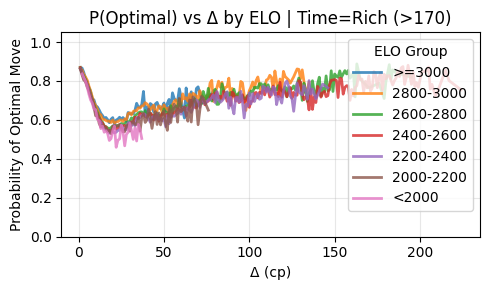

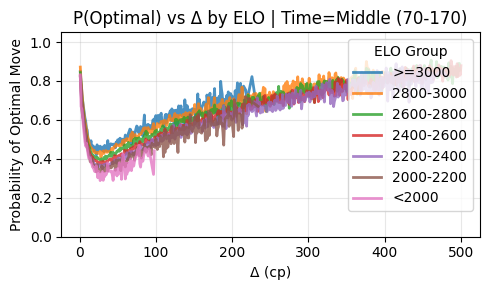

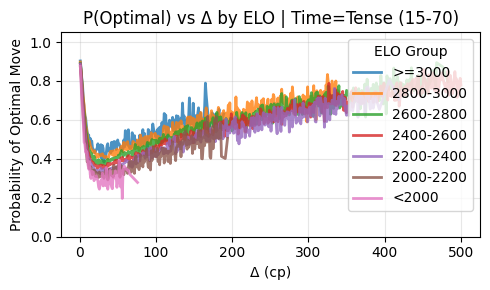

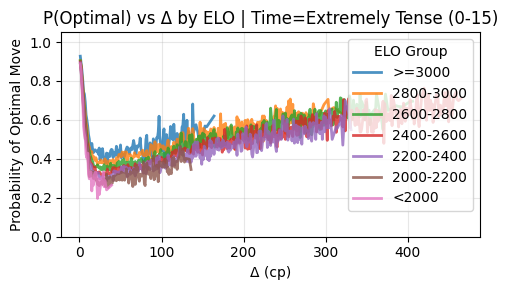

In [30]:
def empirical_curve_v2(df, label, delta_max=1000, show_plot=True):
    # 只过滤非强制着法 和 过滤 Δ 范围
    group_df = df[df['Is_Forced'] == 0].copy()
    group_df = group_df[(group_df['Δ'] > 0) & (group_df['Δ'] <= delta_max)]
    
    if group_df.empty:
        print(f"Warning: No data for {label}")
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    counts = group_df.groupby('Δ', observed=True)['Is_Optimal'].count()
    valid_deltas = counts[counts >= 100].index   #50可以调
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty:
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    # 统计概率，prob_df包含每个Δ和对应的最优步概率
    prob_df = group_df.groupby('Δ', observed=True)['Is_Optimal'].mean().reset_index()
    prob_df.rename(columns={'Is_Optimal': 'P_Optimal'}, inplace=True)
    
    return prob_df

# 按照时间紧张程度看不同elo组的表现情况
all_prob_curves_time = {}
time_groups = df_moves['Time_Group'].unique()
elo_groups = df_moves['ELO_Group'].unique()

for t_group in time_groups:
    all_prob_curves_time[t_group] = {}
    for e_group in elo_groups:
        # 在此处进行精确过滤
        sub_df = df_moves[(df_moves['Time_Group'] == t_group) & (df_moves['ELO_Group'] == e_group)]
        
        print(f"正在处理: Time={t_group}, ELO={e_group}, Samples={len(sub_df)}")
        
        prob_curve = empirical_curve_v2(
            df = sub_df,
            label = f'{e_group} | {t_group}',
            delta_max = 500,
            show_plot = False # 循环中关闭单图，最后一起画总图
        )
        all_prob_curves_time[t_group][e_group] = prob_curve
# 具体画图
for t_group in time_groups:
    plt.figure(figsize=(5,3))
    elo_order=['>=3000', '2800-3000', '2600-2800',
               '2400-2600', '2200-2400', '2000-2200', '<2000']
    colors = plt.cm.tab10.colors

    for i, e_group in enumerate(elo_order):
        if e_group not in all_prob_curves_time[t_group]:
            continue

        curve = all_prob_curves_time[t_group][e_group]
        if curve is None or curve.empty:
            continue

        plt.plot(
            curve['Δ'],
            curve['P_Optimal'],
            lw=2,
            color=colors[i % len(colors)],
            alpha=0.8,
            label=e_group
        )

    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'P(Optimal) vs Δ by ELO | Time={t_group}')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend(title='ELO Group')
    plt.tight_layout()
    plt.show()


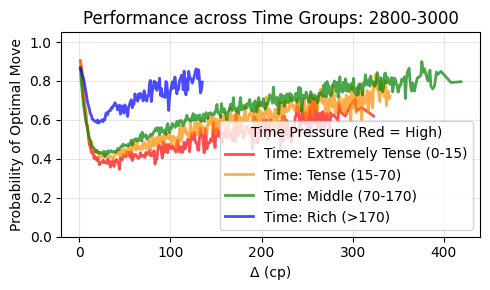

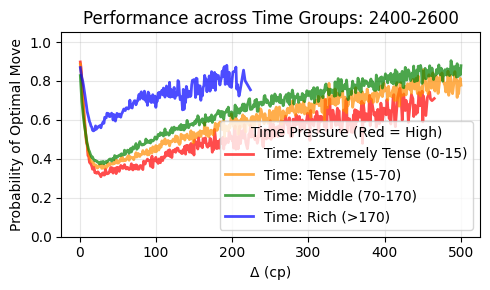

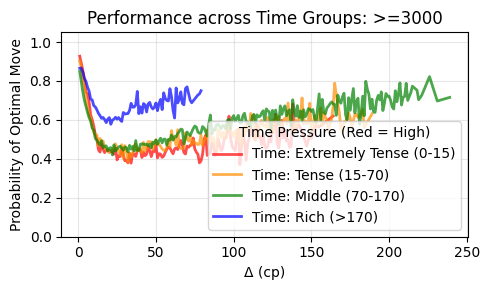

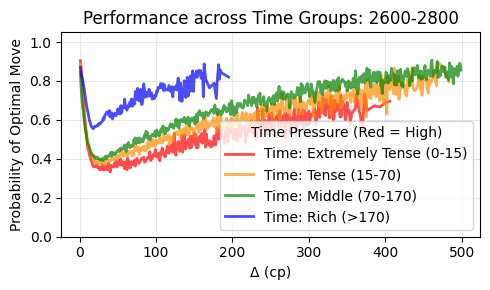

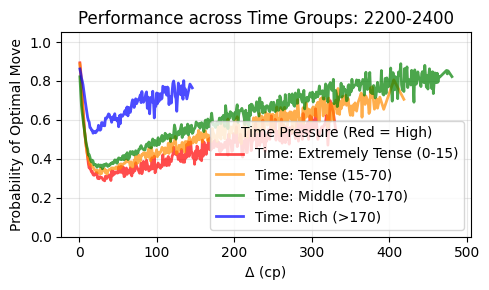

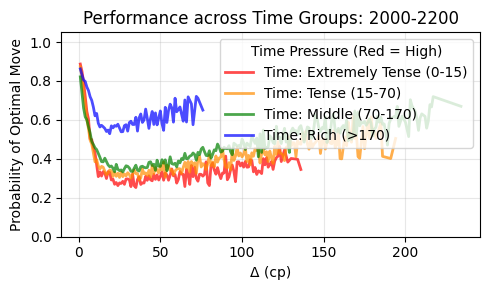

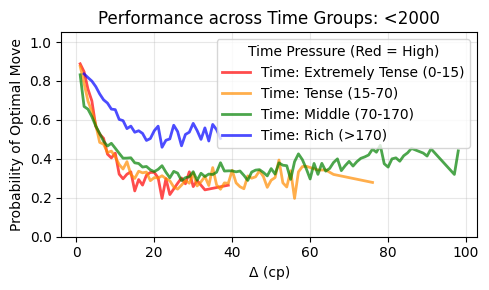

In [31]:
time_color_map = {
    'Extremely Tense (0-15)': 'red',
    'Tense (15-70)': 'darkorange',
    'Middle (70-170)': 'green',
    'Rich (>170)': 'blue'
}

legend_order = [
    'Extremely Tense (0-15)',
    'Tense (15-70)',
    'Middle (70-170)',
    'Rich (>170)'
]

for e_group in elo_groups:
    plt.figure(figsize=(5, 3))

    for t_group in legend_order:
        curve = all_prob_curves_time[t_group].get(e_group)
        if curve is None or curve.empty:
            continue

        plt.plot(
            curve['Δ'],
            curve['P_Optimal'],
            lw=2,
            alpha=0.7,
            color=time_color_map[t_group],
            label=f'Time: {t_group}'
        )

    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'Performance across Time Groups: {e_group}')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)

    # —— 手动控制 legend 顺序 ——
    handles, labels = plt.gca().get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    ordered_handles = []
    ordered_labels = []

    for t in legend_order:
        label = f'Time: {t}'
        if label in label_to_handle:
            ordered_handles.append(label_to_handle[label])
            ordered_labels.append(label)

    plt.legend(
        ordered_handles,
        ordered_labels,
        title="Time Pressure (Red = High)"
    )

    plt.tight_layout()
    plt.show()


# Time-Weighted

In [32]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,...,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170)
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,...,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170)
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,...,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170)
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,...,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170)
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,...,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170)


In [33]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [34]:
def safe_literal_eval(val):
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val

clock_info['white_durations'] = clock_info['white_durations'].progress_apply(safe_literal_eval)
clock_info['black_durations'] = clock_info['black_durations'].progress_apply(safe_literal_eval)

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

In [35]:
time_lookup = clock_info.set_index('uid')[['white_durations', 'black_durations']].to_dict('index')
def get_move_duration(row):
    uid = row['uid']
    move_idx = row['Move_Idx']
    color = row['Color']
    
    # 1. 检查该局游戏是否存在于时间表中
    if uid not in time_lookup:
        return None
    
    # 2. 根据颜色选择对应的时间列表
    game_times = time_lookup[uid]
    if color == 'White':
        durations = game_times['white_durations']
    elif color == 'Black':
        durations = game_times['black_durations']
    else:
        return None
        
    # 3. 计算列表索引 (关键数学逻辑)
    # Move_Idx: 1, 2, 3, 4 ...
    # Index:    0, 0, 1, 1 ...
    list_index = (move_idx - 1) // 2
    
    # 4. 安全提取 (防止索引越界)
    if durations and 0 <= list_index < len(durations):
        return durations[list_index]
    else:
        return None

# 4. 应用到 df_moves
print("正在匹配时间数据...")
df_moves['Move_Time'] = df_moves.progress_apply(get_move_duration, axis=1)

# 5. 检查结果
print(df_moves[['uid', 'Move_Idx', 'Color', 'Move_Time']].head(10))

正在匹配时间数据...


  0%|          | 0/9086334 [00:00<?, ?it/s]

   uid  Move_Idx  Color  Move_Time
0   34         1  White        1.3
1   34         2  Black       -0.9
2   34         3  White       -0.7
3   34         4  Black        0.4
4   34         5  White        0.1
5   34         6  Black        0.0
6   34         7  White       -0.5
7   34         8  Black       -0.2
8   34         9  White        0.2
9   34        10  Black       -0.5


In [36]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,...,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,...,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170),-0.9
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,...,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170),-0.7
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,...,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,...,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1


In [37]:
time_complex = (df_moves .copy()
    .loc[df_moves['Move_Time'].notna() & (df_moves['Move_Time'] >= 0)]
    .reset_index(drop=True)
)
print(time_complex.shape)
print(df_moves.shape)
time_complex.head()

(6686325, 22)
(9086334, 22)


,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,...,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3
1,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,...,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4
2,34,5,Dennis Wagner,White,32,44,35,26,21,21,...,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1
3,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,...,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0
4,34,9,Dennis Wagner,White,32,39,23,17,12,11,...,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2


In [38]:
df_moves.to_csv('0211.csv')

# 运行到这里停一下，新开一个notebook

| ELO 组     | A（能力上限） | 0.73·A | 反解得到的 Δ₀ (cp) |
| --------- | ------- | ------ | ------------- |
| ≥ 3000    | 0.772   | 0.563  | **105.3**     |
| 2800–3000 | 0.749   | 0.547  | **113.3**     |
| 2600–2800 | 0.733   | 0.535  | **118.5**     |
| 2400–2600 | 0.712   | 0.519  | **122.5**     |
| 2200–2400 | 0.691   | 0.505  | **138.3**     |
| 2000–2200 | 0.679   | 0.496  | **129.8**     |
| < 2000    | 0.656   | 0.479  | **can't estimate by now**    |


In [40]:
GLOBAL_DELTA_0 = 10.0  #论文的值10cp画出来的图分布太不平衡了，改成我自己求出来的中间的数字100cp

# 1. 计算 P (向量化)
# 使用 np.exp 可以直接处理整个数组
# 这里的 clip 是为了防止溢出
delta_values = time_complex['Δ'].values
p_values = 1 / (1 + np.exp(-delta_values / GLOBAL_DELTA_0))

# 赋值 P
time_complex['P_optimal(Global)'] = p_values

# 2. 计算 S (向量化)
# 处理 P=0 的情况，防止 log 报错
# 使用 np.where: 如果 p > 1e-9 就算 log，否则设为 1.0
time_complex['S(Global)'] = np.where(
    p_values > 1e-9, 
    -np.log2(p_values), 
    1.0
)

# 3. 计算 S/t (向量化)
# 处理时间为 0 的情况
safe_time = time_complex['Move_Time'].replace(0, 0.1) # 把0秒替换成0.1秒
time_complex['Cognitive_Speed(Global)'] = time_complex['S(Global)'] / safe_time

print("计算完成！")

计算完成！


看一下分布，感觉10cp可能会导致全混在一起、

In [ ]:
time_complex['Game_Length'] = (
    time_complex.groupby('uid')['Move_Idx'].transform('max')
)

time_complex['Progress'] = (
    time_complex['Move_Idx'] / time_complex['Game_Length']
)
complex_drop_opening = time_complex[
    (time_complex['Progress'] > 0.20) &   # 去掉前15%
    (time_complex['Is_Forced'] == 0)
].copy()

In [ ]:
plt.figure(figsize=(15, 5))
# P distribution
plt.subplot(1, 3, 1)
sns.histplot(complex_drop_opening['P_optimal(Global)'], bins=30, kde=True)
plt.title('Distribution of P_optimal(Global)')
plt.xlabel('Probability')
# S distribution
plt.subplot(1, 3, 2)
sns.histplot(complex_drop_opening['S(Global)'], bins=30, kde=True, color='orange')
plt.title('Distribution of Difficulty (Bits)')
plt.xlabel('Entropy S(Global)')
# Cognitive distribution
plt.subplot(1, 3, 3)
# 截断一下长尾，看主体分布
sns.histplot(complex_drop_opening['Cognitive_Speed(Global)'].clip(upper=5), bins=30, kde=True, color='green')
plt.title('Cognitive_Speed(Global) (Bits/sec)')
plt.xlabel('Speed')

plt.tight_layout()
plt.show()

In [ ]:
complex_drop_opening.head()

In [ ]:
# 1. 准备工作：定义分组阈值字典
delta0_map = {
    '>=3000': 105.3,
    '2800-3000': 113.3,
    '2600-2800': 118.5,
    '2400-2600': 122.5,
    '2200-2400': 138.3,
    '2000-2200': 129.8,
    '<2000': 140.0,     # 手动补全
    'Unknown': 120.0    # 默认值
}

# 2. 关键步骤：利用 map 生成一列对齐的 Delta0
# 这行代码会瞬间给几百万行数据填上对应的 Delta0
complex_drop_opening['Delta0_Group'] = complex_drop_opening['ELO_Group'].map(delta0_map)

# 处理一下 map 之后可能产生的 NaN (如果有漏掉的组)，填充为默认值 100
complex_drop_opening['Delta0_Group'] = complex_drop_opening['Delta0_Group'].fillna(100.0)

print("Delta0 分组列生成完毕！预览：")
print(complex_drop_opening[['ELO_Group', 'Delta0_Group']].head())

# --- 开始向量化计算 ---

# 1. 计算 P (Group specific)
# 公式： 1 / (1 + exp(-Δ / Δ0_group))
delta_values = complex_drop_opening['Δ'].values
d0_values = complex_drop_opening['Delta0_Group'].values  # 取出这一列作为分母数组

# 同样使用 numpy 向量运算
p_values_group = 1 / (1 + np.exp(-delta_values / d0_values))

# 赋值 (不带 Global 后缀)
complex_drop_opening['P_optimal'] = p_values_group

# 2. 计算 S (Group specific)
# 同样处理 P接近0 的情况
complex_drop_opening['S'] = np.where(
    p_values_group > 1e-9, 
    -np.log2(p_values_group), 
    1.0
)

# 3. 计算 S/t (Group specific)
# 处理时间为 0 的情况
safe_time = complex_drop_opening['Move_Time'].replace(0, 0.1) 
complex_drop_opening['Cognitive_Speed'] = complex_drop_opening['S'] / safe_time

print("分组指标 (P_optimal, S, Cognitive_Speed) 计算完成！")

In [ ]:
time_complex.head()

In [ ]:
complex_drop_opening.head()

In [ ]:
complex_drop_opening.columns

In [ ]:
# 过滤数据用于画图 (去掉开局和强制步)
plt.figure(figsize=(15, 5))

# 图1: P distribution (Group Specific)
plt.subplot(1, 3, 1)
sns.histplot(complex_drop_opening['P_optimal'], bins=30, kde=True)
plt.title('Distribution of P_optimal (Group Specific)')
plt.xlabel('Probability')

# 图2: S distribution (Group Specific)
plt.subplot(1, 3, 2)
sns.histplot(complex_drop_opening['S'], bins=30, kde=True, color='orange')
plt.title('Distribution of Difficulty S (Bits)')
plt.xlabel('Entropy S')

# 图3: Cognitive Speed distribution (Group Specific)
plt.subplot(1, 3, 3)
sns.histplot(complex_drop_opening['Cognitive_Speed'].clip(upper=5), bins=30, kde=True, color='green')
plt.title('Cognitive_Speed (Bits/sec)')
plt.xlabel('Speed')

plt.tight_layout()
plt.show()

In [ ]:
# 画S（Global和非Global）和P_Optimal的关系
def plot_difficulty_curve(data, x_col, title, ax):
    # 1. 分桶：把 S 切分成 20 个小区间 (0 到 1.0)
    # 使用 pd.cut 把连续的 S 变成区间
    data['S_Bin'] = pd.cut(data[x_col], bins=np.linspace(0, 1.0, 25))
    
    # 2. 聚合：计算每个区间、每个组的 实际准确率 (Is_Optimal)
    agg_data = (
        data.groupby(['ELO_Group', 'S_Bin'])['Is_Optimal']
        .mean()
        .reset_index()
        .rename(columns={'Is_Optimal': 'Actual_Win_Rate'})
    )
    
    # 3. 处理 X 轴：把区间 (0.1, 0.15] 变成中点 0.125 方便画图
    agg_data['S_Mid'] = agg_data['S_Bin'].apply(lambda x: x.mid)
    
    # 4. 画线
    sns.lineplot(
        data=agg_data, 
        x='S_Mid', 
        y='Actual_Win_Rate', 
        hue='ELO_Group', 
        hue_order=elo_order,
        marker='o',
        linewidth=2,
        ax=ax
    )
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Difficulty S (Bits)', fontsize=12)
    ax.set_ylabel('Actual Probability of Optimal Move', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 1.0)
    ax.grid(True, alpha=0.3)
    # 添加对角线参考 (理论预测)
    # 理论上 P = 2^(-S)，可以画一条虚线对比实际值
    x_ref = np.linspace(0, 1, 100)
    y_ref = 2 ** (-x_ref)
    ax.plot(x_ref, y_ref, 'k--', alpha=0.5, label='Theoretical Model')


# --- 开始画图 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 图1：Global Standard (展示能力差距)
plot_difficulty_curve(
    complex_drop_opening.copy(), 
    x_col='S(Global)', 
    title='(A) Global Standard (Δ0=100cp)\nSeparation shows Skill Gap', 
    ax=axes[0]
)

# 图2：Group Specific (展示规律统一)
plot_difficulty_curve(
    complex_drop_opening.copy(), 
    x_col='S', 
    title='(B) Normalized by Skill (Group Δ0)\nCurves Collapse = Universal Law', 
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
# 过滤掉极端值以便观察
speed_df = complex_drop_opening[complex_drop_opening['Cognitive_Speed(Global)'] < 5].copy()
sns.boxplot(
    data=speed_df,
    x='ELO_Group',
    y='Cognitive_Speed(Global)',
    order=elo_order,
    palette='viridis',
    showfliers=False  # 不显示离群点，让箱体更清晰
)
plt.title('Cognitive Processing Speed by Skill Level')
plt.ylabel('Bits per Second (Global Standard)')
plt.xlabel('ELO Group')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
# 过滤掉极端值以便观察
speed_df = complex_drop_opening[complex_drop_opening['Cognitive_Speed'] < 5].copy()
sns.boxplot(
    data=speed_df,
    x='ELO_Group',
    y='Cognitive_Speed',
    order=elo_order,
    palette='viridis',
    showfliers=False  # 不显示离群点，让箱体更清晰
)
plt.title('Cognitive Processing Speed by Skill Level')
plt.ylabel('Bits per Second')
plt.xlabel('ELO Group')
plt.grid(axis='y', alpha=0.3)
plt.show() 

In [ ]:
plt.figure(figsize=(10, 6))

# --- 关键修改：只看难题 ---
# 过滤 S(Global) > 0.5 的局面
# 意思是：只看那些真正需要动脑子的棋，这时候谁脑子快一目了然
difficult_moves = complex_drop_opening[
    (complex_drop_opening['S(Global)'] > 0.4) & 
    (complex_drop_opening['S(Global)'] < 0.9) &
    (complex_drop_opening['Cognitive_Speed(Global)'] < 5) &
    (complex_drop_opening['Move_Time'] > 1.0)
].copy()

sns.boxplot(
    data=difficult_moves,
    x='ELO_Group',
    y='Cognitive_Speed(Global)',
    order=elo_order,
    palette='viridis',
    showfliers=False
)

plt.title('Cognitive Speed in Complex Positions (S > 0.5 bits)') # 标题改一下
plt.ylabel('Bits per Second')
plt.xlabel('ELO Group')
plt.show()

棋局复杂度与棋手失误类型的关系

# Complexity 高低 → Blunder / Mistake 发生概率

In [39]:
pd.set_option('display.max_columns', None)
complex_drop_opening.head()

NameError: name 'complex_drop_opening' is not defined

In [ ]:
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Count', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color)
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show()
#mistake blunder distribution
# 只保留错误步
errors_df = complex_drop_opening[complex_drop_opening['Is_Error']==1]

plot_hist_with_values(df=complex_drop_opening, col='S', bins=50, kde=True, title="Mistake / Blunder 's S distribution", xlabel='S', ylabel='Num',color='red')

In [ ]:
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Count', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color)
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show()
#mistake blunder distribution
# 只保留错误步
errors_df = complex_drop_opening[complex_drop_opening['Is_Error']==1]

plot_hist_with_values(df=complex_drop_opening, col='S(Global)', bins=50, kde=True, title="Mistake / Blunder 's S(Global) distribution", xlabel='S(Global)', ylabel='Num',color='red')

In [ ]:
def plot_hist_compare_by_elo(df, elo_order, bins=50, kde=True):
    for elo in elo_order:
        sub_df = df[df['ELO_Group'] == elo]

        values_local = sub_df['S'].dropna()
        values_global = sub_df['S(Global)'].dropna()

        fig, axes = plt.subplots(1, 2, figsize=(10, 3))

        # 左图：Group-specific S
        sns.histplot(values_local, bins=bins, kde=kde, ax=axes[0])
        axes[0].set_title(f"{elo} - S")
        axes[0].set_xlabel("S")
        axes[0].set_ylabel("Count")

        # 右图：Global S
        sns.histplot(values_global, bins=bins, kde=kde, ax=axes[1])
        axes[1].set_title(f"{elo} - S (Global)")
        axes[1].set_xlabel("S")
        axes[1].set_ylabel("Count")

        plt.tight_layout()
        plt.show()

plot_hist_compare_by_elo(
    df=errors_df,
    elo_order=elo_order,
    bins=50,
    kde=True
)
